GAN WITH MNIST DATASET

--- Part 1: Loading and Preprocessing the MNIST Dataset ---
Normalized training data shape: (60000, 28, 28, 1)
Example of a normalized pixel value: -1.0

--- Part 2: Building the GAN Components ---


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Generator Model Summary ---



--- Discriminator Model Summary ---


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Part 3: Training Setup ---

Training dataset prepared successfully.
Batch size: 256
Number of epochs: 25
Latent dimension: 100

BEGINNING GAN TRAINING
Epoch 01/25 | Discriminator Loss: 1.0858 | Generator Loss: 0.7154
Epoch 02/25 | Discriminator Loss: 1.2681 | Generator Loss: 0.8003
Epoch 03/25 | Discriminator Loss: 1.1607 | Generator Loss: 0.9676
Epoch 04/25 | Discriminator Loss: 1.2356 | Generator Loss: 0.8860
Epoch 05/25 | Discriminator Loss: 1.2608 | Generator Loss: 0.8817


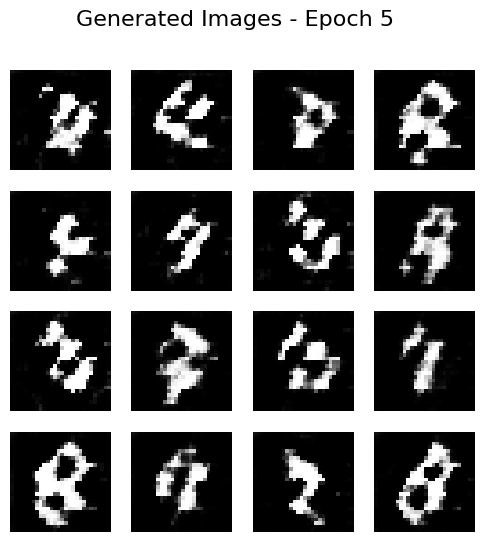

Image saved: images/image_at_epoch_0005.png
Epoch 06/25 | Discriminator Loss: 1.2806 | Generator Loss: 0.8376
Epoch 07/25 | Discriminator Loss: 1.3100 | Generator Loss: 0.8532
Epoch 08/25 | Discriminator Loss: 1.2769 | Generator Loss: 0.8677
Epoch 09/25 | Discriminator Loss: 1.3161 | Generator Loss: 0.8556
Epoch 10/25 | Discriminator Loss: 1.2233 | Generator Loss: 0.8995


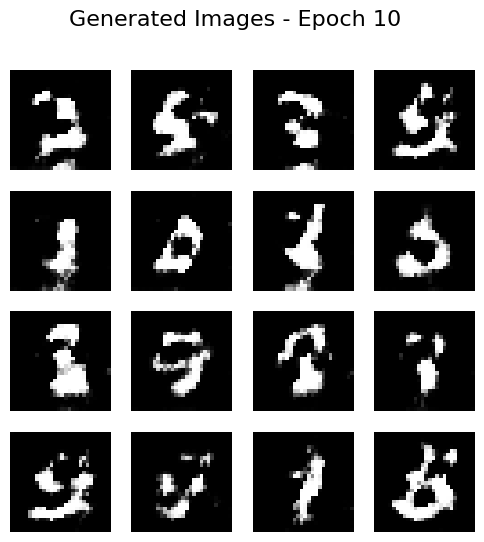

Image saved: images/image_at_epoch_0010.png
Epoch 11/25 | Discriminator Loss: 1.2624 | Generator Loss: 0.8780
Epoch 12/25 | Discriminator Loss: 1.2751 | Generator Loss: 0.8565
Epoch 13/25 | Discriminator Loss: 1.2233 | Generator Loss: 0.9672
Epoch 14/25 | Discriminator Loss: 1.1545 | Generator Loss: 0.9789
Epoch 15/25 | Discriminator Loss: 1.1825 | Generator Loss: 0.9733


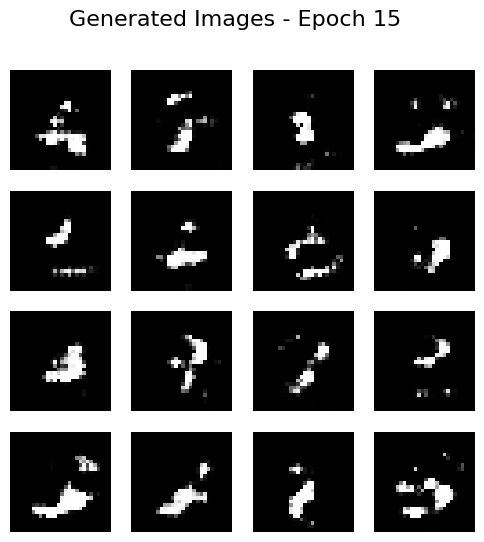

Image saved: images/image_at_epoch_0015.png
Epoch 16/25 | Discriminator Loss: 1.1576 | Generator Loss: 1.0708
Epoch 17/25 | Discriminator Loss: 1.1422 | Generator Loss: 1.0361
Epoch 18/25 | Discriminator Loss: 1.0241 | Generator Loss: 1.2412
Epoch 19/25 | Discriminator Loss: 1.0875 | Generator Loss: 1.1630
Epoch 20/25 | Discriminator Loss: 1.1124 | Generator Loss: 1.1341


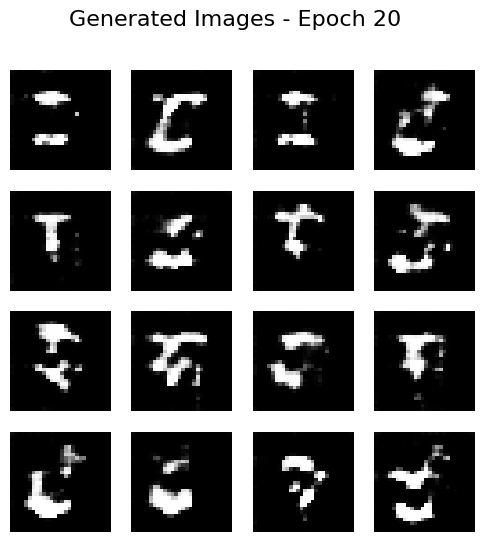

Image saved: images/image_at_epoch_0020.png
Epoch 21/25 | Discriminator Loss: 0.9312 | Generator Loss: 1.3169
Epoch 22/25 | Discriminator Loss: 1.1130 | Generator Loss: 1.1610
Epoch 23/25 | Discriminator Loss: 0.9516 | Generator Loss: 1.3265
Epoch 24/25 | Discriminator Loss: 1.0101 | Generator Loss: 1.2231
Epoch 25/25 | Discriminator Loss: 1.0102 | Generator Loss: 1.2770


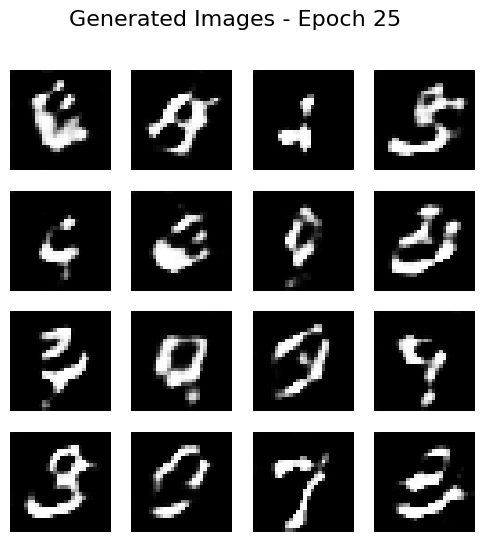

Image saved: images/image_at_epoch_0025.png

TRAINING COMPLETE

Generating final images...


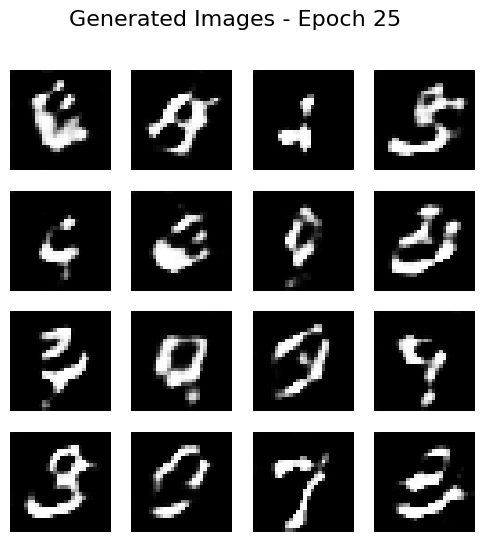

Image saved: images/image_at_epoch_0025.png

--- GAN PROGRAM EXECUTION COMPLETED ---


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
import os

tf.keras.utils.disable_interactive_logging()

print("=" * 60)
print("GAN WITH MNIST DATASET")
print("=" * 60)

print("\n--- Part 1: Loading and Preprocessing the MNIST Dataset ---")

(x_train, _), (_, _) = mnist.load_data()

x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype("float32")
x_train = (x_train - 127.5) / 127.5

print("Normalized training data shape:", x_train.shape)
print("Example of a normalized pixel value:", x_train[0, 0, 0, 0])

print("\n--- Part 2: Building the GAN Components ---")

latent_dim = 100

def build_generator():
    model = keras.Sequential(name="generator")

    model.add(
        layers.Dense(
            7 * 7 * 256,
            use_bias=False,
            input_shape=(latent_dim,)
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.Reshape((7, 7, 256)))

    model.add(
        layers.Conv2DTranspose(
            128,
            (5, 5),
            strides=(1, 1),
            padding="same",
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(
        layers.Conv2DTranspose(
            64,
            (5, 5),
            strides=(2, 2),
            padding="same",
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(
        layers.Conv2DTranspose(
            1,
            (5, 5),
            strides=(2, 2),
            padding="same",
            use_bias=False,
            activation="tanh"
        )
    )

    return model


generator = build_generator()

print("\n--- Generator Model Summary ---")
generator.summary()

def build_discriminator():
    model = keras.Sequential(name="discriminator")

    model.add(
        layers.Conv2D(
            64,
            (5, 5),
            strides=(2, 2),
            padding="same",
            input_shape=[28, 28, 1]
        )
    )

    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(
        layers.Conv2D(
            128,
            (5, 5),
            strides=(2, 2),
            padding="same"
        )
    )

    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation="sigmoid"))

    return model


discriminator = build_discriminator()

print("\n--- Discriminator Model Summary ---")
discriminator.summary()

print("\n--- Part 3: Training Setup ---")

cross_entropy = keras.losses.BinaryCrossentropy(
    from_logits=False
)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    return real_loss + fake_loss


def generator_loss(fake_output):
    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )


generator_optimizer = keras.optimizers.Adam(
    learning_rate=1e-4
)

discriminator_optimizer = keras.optimizers.Adam(
    learning_rate=1e-4
)

EPOCHS = 25
BATCH_SIZE = 256
num_examples_to_generate = 16

seed = tf.random.normal(
    [num_examples_to_generate, latent_dim]
)

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(x_train)
    .shuffle(x_train.shape[0])
    .batch(BATCH_SIZE, drop_remainder=True)
)

@tf.function
def train_step(images):

    noise = tf.random.normal(
        [BATCH_SIZE, latent_dim]
    )

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        generated_images = generator(
            noise,
            training=True
        )

        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        gen_loss = generator_loss(fake_output)

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            gradients_of_generator,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            gradients_of_discriminator,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss


def generate_and_save_images(
    model,
    epoch,
    test_input
):

    predictions = model(
        test_input,
        training=False
    )

    predictions_rescaled = (
        predictions * 0.5
    ) + 0.5

    fig = plt.figure(
        figsize=(6, 6)
    )

    for i in range(
        predictions.shape[0]
    ):

        plt.subplot(
            4,
            4,
            i + 1
        )

        plt.imshow(
            predictions_rescaled[i, :, :, 0],
            cmap="gray"
        )

        plt.axis("off")

    plt.suptitle(
        "Generated Images - Epoch " + str(epoch),
        fontsize=16
    )

    os.makedirs(
        "images",
        exist_ok=True
    )

    filename = (
        "images/image_at_epoch_"
        + str(epoch).zfill(4)
        + ".png"
    )

    plt.savefig(
        filename,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    print("Image saved:", filename)


def train(
    dataset,
    epochs
):

    print("\n" + "=" * 60)
    print("BEGINNING GAN TRAINING")
    print("=" * 60)

    for epoch in range(epochs):

        gen_loss_list = []
        disc_loss_list = []

        for image_batch in dataset:

            gen_loss, disc_loss = train_step(
                image_batch
            )

            gen_loss_list.append(
                gen_loss.numpy()
            )

            disc_loss_list.append(
                disc_loss.numpy()
            )

        avg_gen_loss = np.mean(
            gen_loss_list
        )

        avg_disc_loss = np.mean(
            disc_loss_list
        )

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Discriminator Loss: {avg_disc_loss:.4f} | "
            f"Generator Loss: {avg_gen_loss:.4f}"
        )

        if (epoch + 1) % 5 == 0:
            generate_and_save_images(
                generator,
                epoch + 1,
                seed
            )

    print("\n" + "=" * 60)
    print("TRAINING COMPLETE")
    print("=" * 60)

    print("\nGenerating final images...")

    generate_and_save_images(
        generator,
        epochs,
        seed
    )


print("\nTraining dataset prepared successfully.")
print("Batch size:", BATCH_SIZE)
print("Number of epochs:", EPOCHS)
print("Latent dimension:", latent_dim)

train(
    train_dataset,
    EPOCHS
)

print("\n--- GAN PROGRAM EXECUTION COMPLETED ---")